<a href="https://colab.research.google.com/github/Gdearmascasta/Entregas_data/blob/main/Imputacio%CC%81n_y_Evaluacio%CC%81n_de_Datos_Faltantes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Imputación y Evaluación de Datos Faltantes**
<img src="https://upload.wikimedia.org/wikipedia/commons/b/b3/Universidad_Tecnol%C3%B3gica_de_Bol%C3%ADvar.png" width="100"></br>
**Nombres y Códigos:**</br>
<ul>
  <li>German Eduardo De Armas Castaño - T00068765</li>
  <li>Isaac David Sánchez Sánchez – T00067613</li>
  <li>Luis Mario Diaz Martinez – T00069220</li>
  <li>Maria Valentina Serna Gonzalez – T00067756</li>
</ul>


**Objetivo:** Analizar el impacto de los datos faltantes en la precisión de la imputación mediante técnicas de media y mediana, evaluando el comportamiento del Error Cuadrático Medio (MSE) conforme aumenta el porcentaje de valores faltantes, y visualizando los resultados con histogramas y gráficos de dispersión.

## 📦 Importación de Librerías

En este bloque, importamos las librerías necesarias para realizar la imputación de datos y la evaluación de los resultados:

- **NumPy**: Se utiliza para la manipulación de arreglos multidimensionales y operaciones matemáticas.
- **Pandas**: Nos permite trabajar con estructuras de datos como DataFrames, facilitando la manipulación y análisis de datos.
- **Matplotlib**: Es una librería de visualización que se utilizará para crear gráficos.
- **SimpleImputer** de **scikit-learn**: Esta clase se utiliza para imputar valores faltantes en los datos, permitiendo técnicas como la imputación por la media, mediana, entre otras.
- **mean_squared_error** de **scikit-learn**: Esta función calcula el Error Cuadrático Medio (MSE), que se usará para evaluar la precisión de la imputación comparando los valores originales con los imputados.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error

## 🔢 Generación de una Matriz Aleatoria

En este bloque, generamos una matriz de **5000x20** con valores aleatorios en el rango de **0 a 1** . Además, establecemos una semilla con para asegurar la reproducibilidad de los resultados.
  
Finalmente, se muestra una vista previa de la matriz, para verificar.



In [ ]:
np.random.seed(43)

# Crear una matriz de 5000x20 con valores aleatorios entre 0 y 1
matriz = np.random.rand(5000, 20)

print(matriz)

[[0.11505457 0.60906654 0.13339096 ... 0.31609647 0.0766627  0.84322469]
 [0.84893915 0.97146509 0.38537691 ... 0.52525567 0.10401895 0.1809146 ]
 [0.95304022 0.41195298 0.86501712 ... 0.70471561 0.60955987 0.54003446]
 ...
 [0.84614603 0.08368038 0.43031172 ... 0.55061768 0.24171991 0.90220829]
 [0.17822627 0.09030373 0.13160791 ... 0.44878324 0.39916998 0.53941955]
 [0.97273317 0.94597652 0.18549323 ... 0.79800633 0.49221792 0.08466772]]


## 📉 Introducción de Valores Faltantes (NaN)

En este bloque, simulamos la introducción de valores faltantes (NaN) en la matriz generada previamente. Lo hacemos para diferentes porcentajes de valores faltantes, que varían entre un **5%** y un **90%**.

### Proceso:
1. **Definición de Porcentajes de NaN**: Se establece una lista con los porcentajes de valores faltantes que se desean introducir en la matriz, que van desde el 5% hasta el 90%.
2. **Cálculo del Número de Valores Faltantes**: Para cada porcentaje, se calcula cuántos elementos de la matriz deben ser reemplazados por NaN. Esto se obtiene multiplicando el porcentaje por el número total de valores en la matriz.
3. **Selección de Índices Aleatorios**: A continuación, se seleccionan índices aleatorios en la matriz para reemplazarlos por NaN. Esta selección se realiza sin reemplazo, es decir, un valor no puede ser seleccionado más de una vez.
4. **Inserción de NaN**: Los índices seleccionados son convertidos en valores NaN, creando matrices con diferentes proporciones de valores faltantes.
5. **Almacenamiento de las Matrices con NaN**: Cada matriz resultante, con un porcentaje específico de valores faltantes, se almacena en un diccionario. Esto permite tener acceso a las matrices con distintas proporciones de NaN para su posterior análisis.
6. **Entrada del Usuario**: Después de generar las matrices con NaN, se le solicita al usuario que ingrese un porcentaje específico de NaN que desea ver (entre los disponibles en la lista) y se muestra un vista previa de las primeras 10 filas de la matriz.

Este proceso permite simular cómo los datos faltantes afectan el análisis y la imputación en escenarios con diferentes cantidades de valores ausentes.

In [ ]:
# Definir los porcentajes de valores NaN a introducir
porcentajes_nan = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90]

# Crear copias de la matriz original para cada porcentaje de valores faltantes
matrices_con_nan = {}

# Obtener el número total de valores en la matriz
total_valores = matriz.size

np.random.seed(43)

# Introducir valores faltantes para cada porcentaje
for porcentaje in porcentajes_nan:
    matriz_nan = matriz.copy()
    num_nan = int((porcentaje / 100) * total_valores)

    # Seleccionar índices aleatorios para convertir en NaN
    indices = np.random.choice(total_valores, num_nan, replace=False)
    filas, columnas = np.unravel_index(indices, matriz.shape)

    # Insertar NaN en la matriz
    matriz_nan[filas, columnas] = np.nan

    # Guardar la matriz con valores faltantes
    matrices_con_nan[porcentaje] = matriz_nan

# Solicitar al usuario que ingrese el porcentaje de NaN que desea
porcentaje_nan = int(input(f"Introduce el porcentaje de NaN de la matriz que deseas ver ({', '.join(map(str, porcentajes_nan))}): "))

# Verificar si el porcentaje introducido es válido
if porcentaje_nan in matrices_con_nan:
    df_nan = pd.DataFrame(matrices_con_nan[porcentaje_nan])

    # Mostrar las primeras 10 filas del DataFrame
    print("\nPrimeras 10 filas de la matriz con NaN:")
    print(df_nan.head(10))
else:
    print("Porcentaje no válido. Por favor, ingresa un valor de la lista.")

Introduce el porcentaje de NaN de la matriz que deseas ver (5, 10, 20, 30, 40, 50, 60, 70, 80, 90): 20

Primeras 10 filas de la matriz con NaN:
           0           1           2           3           4          5   \
0   85.147999   61.830371   72.429938   69.301688         NaN  71.739800   
1   80.280811   76.783406  124.607193   72.017686   81.088891  97.683636   
2  104.424319  100.299770         NaN  125.325854   68.100887  68.374609   
3   80.104114   93.830638   88.897243   81.805591   42.833142  76.668399   
4   83.256363   77.710160  103.729369   83.595833  110.328832  47.319360   
5   84.073508   42.869586   87.563789  104.722806   66.200564  76.032906   
6         NaN   94.367016         NaN   76.839419   68.315697  78.593870   
7   57.530734   86.679302   69.855391   99.803003  105.158879  83.552498   
8   91.626815   57.337998         NaN   95.060926         NaN  68.965888   
9   82.692729   98.599795   81.157789   72.408327  101.079062  99.926267   

           6       

# 🧑‍💻 Imputación de Valores Faltantes por la Media/Mediana

En este caso, vamos a utilizar dos métodos diferentes para imputar valores faltantes en una matriz de datos.

- El **primer método** es el que se presentó en clase, donde calculamos la media o la mediana de cada columna ignorando los valores NaN, y luego reemplazamos esos valores faltantes con estos cálculos.

- El **segundo método**, en cambio, utiliza librerías ya existentes, como `sklearn.impute`, para realizar la imputación de forma más eficiente y con un código más compacto.

Ambos métodos nos permitirán comparar su efectividad y desempeño al manejar datos incompletos.


### 👨🏻‍🏫 Primer método (Presentado en clases)  

El usuario debe elegir un porcentaje de datos faltantes para analizar cómo afecta la cantidad de valores ausentes en el proceso de imputación. Dependiendo del porcentaje seleccionado, se genera una matriz con valores faltantes, sobre la cual se aplican las técnicas de imputación.  



In [ ]:
# Función para imputar valores faltantes con la media
def imputar_media(matriz):
    matriz_imputada = matriz.copy()  # Crear copia para no modificar la original
    col_means = np.nanmean(matriz_imputada, axis=0)  # Media ignorando NaN
    indices_nan = np.where(np.isnan(matriz_imputada))  # Posiciones de NaN
    matriz_imputada[indices_nan] = np.take(col_means, indices_nan[1])  # Reemplazar NaN con la media
    return matriz_imputada

# Función para imputar valores faltantes con la mediana
def imputar_mediana(matriz):
    matriz_imputada = matriz.copy()  # Crear copia para no modificar la original
    col_medians = np.nanmedian(matriz_imputada, axis=0)  # Mediana ignorando NaN
    indices_nan = np.where(np.isnan(matriz_imputada))  # Posiciones de NaN
    matriz_imputada[indices_nan] = np.take(col_medians, indices_nan[1])  # Reemplazar NaN con la mediana
    return matriz_imputada

# Diccionarios para almacenar matrices imputadas
matrices_imputadas_media_clases = {}
matrices_imputadas_mediana_clases = {}

# Aplicar imputación con funciones personalizadas a cada matriz con valores faltantes
for porcentaje, matriz_nan in matrices_con_nan.items():
    matrices_imputadas_media_clases[porcentaje] = imputar_media(matriz_nan)
    matrices_imputadas_mediana_clases[porcentaje] = imputar_mediana(matriz_nan)

# Solicitar al usuario que ingrese el porcentaje de NaN que desea
porcentaje_nan = int(input(f"Introduce el porcentaje de NaN de la matriz que deseas ver ({', '.join(map(str, porcentajes_nan))}): "))

# Capturamos información de los datos nan para ser usados más adelante
data_nan = matrices_con_nan[porcentaje_nan]

# Verificar si el porcentaje introducido es válido
if porcentaje_nan in matrices_con_nan:
    data_media_clases = matrices_imputadas_media_clases[porcentaje_nan]
    data_mediana_clases = matrices_imputadas_mediana_clases[porcentaje_nan]
    # Imprimir las primeras filas después de la imputación
    print("\n Matriz imputada con MEDIA (primeras 5 filas):\n", data_media_clases[:5])
    print("\n Matriz imputada con MEDIANA (primeras 5 filas):\n", data_mediana_clases[:5])
else:
    print("Porcentaje no válido. Por favor, ingresa un valor de la lista.")


Introduce el porcentaje de NaN de la matriz que deseas ver (5, 10, 20, 30, 40, 50, 60, 70, 80, 90): 40

 Matriz imputada con MEDIA (primeras 5 filas):
 [[ 80.59507512  61.83037134  80.20302166  80.61015437  97.16146692
   79.92506546  89.96377169  80.25912184  79.77944495  71.21570286
   79.83065394  80.13289295  80.49871941  80.04467564  80.3692971
   79.77235638 118.70272575  67.6311469   59.06322028  79.88038221]
 [ 80.59507512  76.78340628  80.20302166  72.01768563  80.19572318
   97.6836363   80.07078508  80.25912184  87.89813272  96.74410045
   51.84243659  96.15698827  77.23432711  83.74357171  72.26683729
   79.77235638  79.23491851 107.98633973  66.41985758 110.57970269]
 [104.42431927  80.36056993  80.20302166  80.61015437  68.1008866
   79.92506546  66.88211708  98.50297707  54.01677311  80.4056777
   74.23119634  58.64573869  58.44798205  64.06452474  50.27914836
   90.28257531  79.23491851  80.09159584  67.47031902  86.15862026]
 [ 80.1041137   93.83063815  80.20302166  81

### 📚 Segundo método (Librerias externas)  

Cada matriz con valores faltantes es procesada mediante los imputadores correspondientes. De esta manera, se obtienen versiones imputadas de cada conjunto de datos para los diferentes porcentajes de valores ausentes.  

In [ ]:
# Diccionarios para almacenar matrices imputadas
matrices_imputadas_media_libreria = {}
matrices_imputadas_mediana_libreria = {}

# Creación de los imputadores
imputador_media = SimpleImputer(strategy="mean")
imputador_mediana = SimpleImputer(strategy="median")

# Aplicar imputación a cada matriz con los diferentes % de valores faltantes
for porcentaje, matriz_nan in matrices_con_nan.items():
    matrices_imputadas_media_libreria[porcentaje] = imputador_media.fit_transform(matriz_nan)
    matrices_imputadas_mediana_libreria[porcentaje] = imputador_mediana.fit_transform(matriz_nan)

# Solicitar al usuario que ingrese el porcentaje de NaN que desea ver
porcentaje_nan = int(input(f"Introduce el porcentaje de NaN de la matriz que deseas ver ({', '.join(map(str, matrices_con_nan.keys()))}): "))

# Verificar si el porcentaje introducido es válido
if porcentaje_nan in matrices_imputadas_media_libreria:
    # Obtener las matrices imputadas correspondientes
    data_media_libreria = matrices_imputadas_media_libreria[porcentaje_nan]
    data_mediana_libreria = matrices_imputadas_mediana_libreria[porcentaje_nan]

    # Imprimir las primeras filas después de la imputación
    print("\nMatriz imputada con MEDIA (primeras 5 filas):\n", data_media_libreria[:5])
    print("\nMatriz imputada con MEDIANA (primeras 5 filas):\n", data_mediana_libreria[:5])
else:
    print("Porcentaje no válido. Por favor, ingresa un valor de la lista.")


Introduce el porcentaje de NaN de la matriz que deseas ver (5, 10, 20, 30, 40, 50, 60, 70, 80, 90): 40

Matriz imputada con MEDIA (primeras 5 filas):
 [[ 80.59507512  61.83037134  80.20302166  80.61015437  97.16146692
   79.92506546  89.96377169  80.25912184  79.77944495  71.21570286
   79.83065394  80.13289295  80.49871941  80.04467564  80.3692971
   79.77235638 118.70272575  67.6311469   59.06322028  79.88038221]
 [ 80.59507512  76.78340628  80.20302166  72.01768563  80.19572318
   97.6836363   80.07078508  80.25912184  87.89813272  96.74410045
   51.84243659  96.15698827  77.23432711  83.74357171  72.26683729
   79.77235638  79.23491851 107.98633973  66.41985758 110.57970269]
 [104.42431927  80.36056993  80.20302166  80.61015437  68.1008866
   79.92506546  66.88211708  98.50297707  54.01677311  80.4056777
   74.23119634  58.64573869  58.44798205  64.06452474  50.27914836
   90.28257531  79.23491851  80.09159584  67.47031902  86.15862026]
 [ 80.1041137   93.83063815  80.20302166  81.

### 🟰 Comprobación de igualdad

Ambos métodos deben haber dado los mismos resultados, y esto lo comprobamos en la siguiente celda.

PD: Ahora en adelante usaremos la usada en clases para los demás cálculos.

In [ ]:
# Comparar matrices
for porcentaje in matrices_imputadas_media_clases.keys():
    matriz_clases = matrices_imputadas_media_clases[porcentaje]
    matriz_libreria = matrices_imputadas_media_libreria[porcentaje]

    if np.array_equal(matriz_clases, matriz_libreria):
        print(f"✅ Las matrices imputadas con media para {porcentaje}% de NaN son idénticas.")
    else:
        print(f"❌ Las matrices imputadas con media para {porcentaje}% de NaN son diferentes.")

for porcentaje in matrices_imputadas_mediana_clases.keys():
    matriz_clases = matrices_imputadas_mediana_clases[porcentaje]
    matriz_libreria = matrices_imputadas_mediana_libreria[porcentaje]

    if np.array_equal(matriz_clases, matriz_libreria):
        print(f"✅ Las matrices imputadas con mediana para {porcentaje}% de NaN son idénticas.")
    else:
        print(f"❌ Las matrices imputadas con mediana para {porcentaje}% de NaN son diferentes.")

✅ Las matrices imputadas con media para 5% de NaN son idénticas.
✅ Las matrices imputadas con media para 10% de NaN son idénticas.
✅ Las matrices imputadas con media para 20% de NaN son idénticas.
✅ Las matrices imputadas con media para 30% de NaN son idénticas.
✅ Las matrices imputadas con media para 40% de NaN son idénticas.
✅ Las matrices imputadas con media para 50% de NaN son idénticas.
✅ Las matrices imputadas con media para 60% de NaN son idénticas.
✅ Las matrices imputadas con media para 70% de NaN son idénticas.
✅ Las matrices imputadas con media para 80% de NaN son idénticas.
✅ Las matrices imputadas con media para 90% de NaN son idénticas.
✅ Las matrices imputadas con mediana para 5% de NaN son idénticas.
✅ Las matrices imputadas con mediana para 10% de NaN son idénticas.
✅ Las matrices imputadas con mediana para 20% de NaN son idénticas.
✅ Las matrices imputadas con mediana para 30% de NaN son idénticas.
✅ Las matrices imputadas con mediana para 40% de NaN son idénticas.
✅ 

## 📈 Visualización de la Distribución de los Datos  

Para analizar el impacto de la imputación en la distribución de los datos, se selecciona una columna de la matriz y se comparan sus histogramas antes y después de la imputación. Se representan tres distribuciones:  

- **Datos originales con valores faltantes**   
- **Datos imputados con la media**
- **Datos imputados con la mediana**

Cada distribución se representa con un histograma superpuesto para visualizar las diferencias entre los métodos de imputación. Esto permite evaluar si la estructura original de los datos se conserva o si la imputación introduce sesgos significativos.  


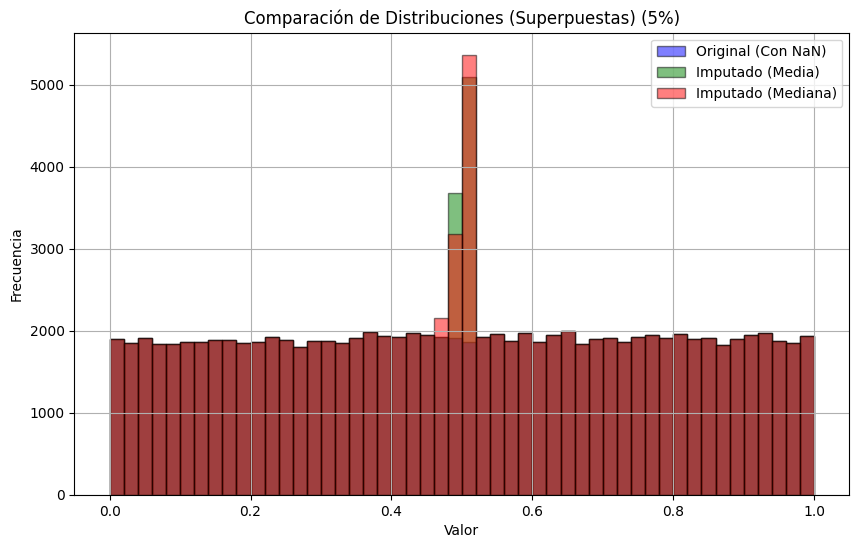

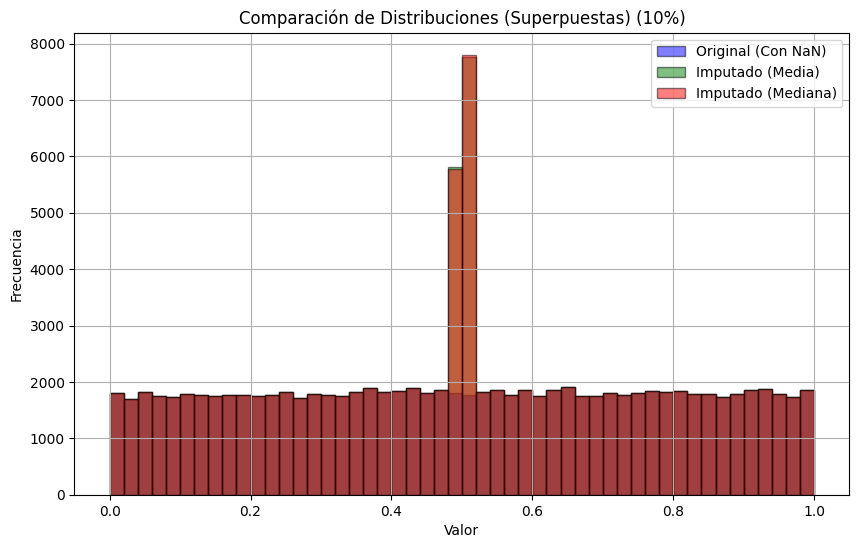

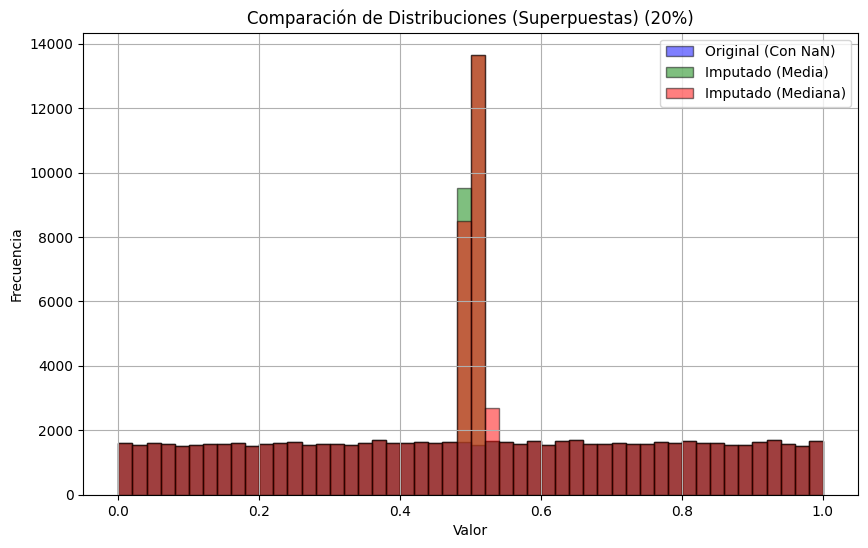

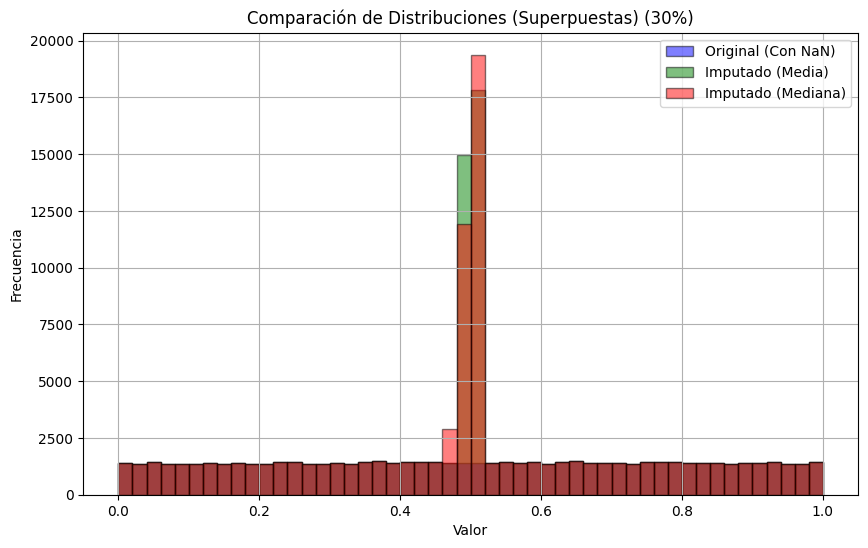

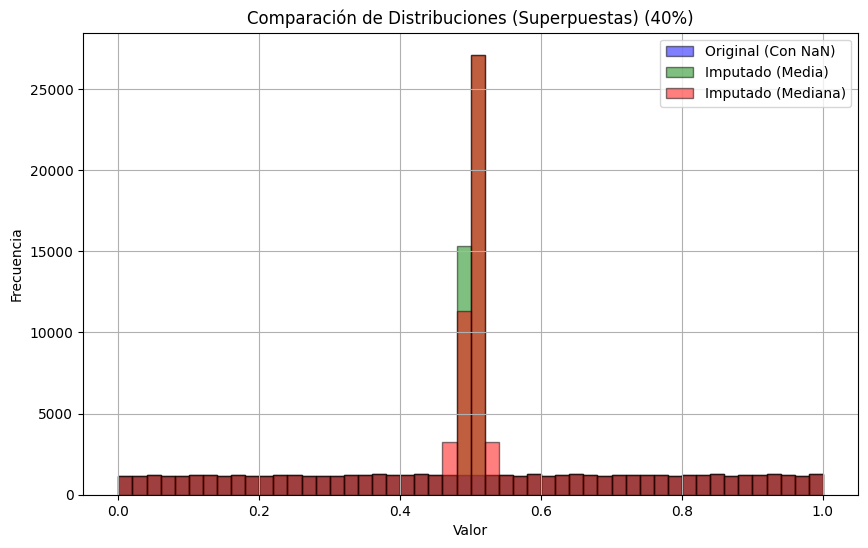

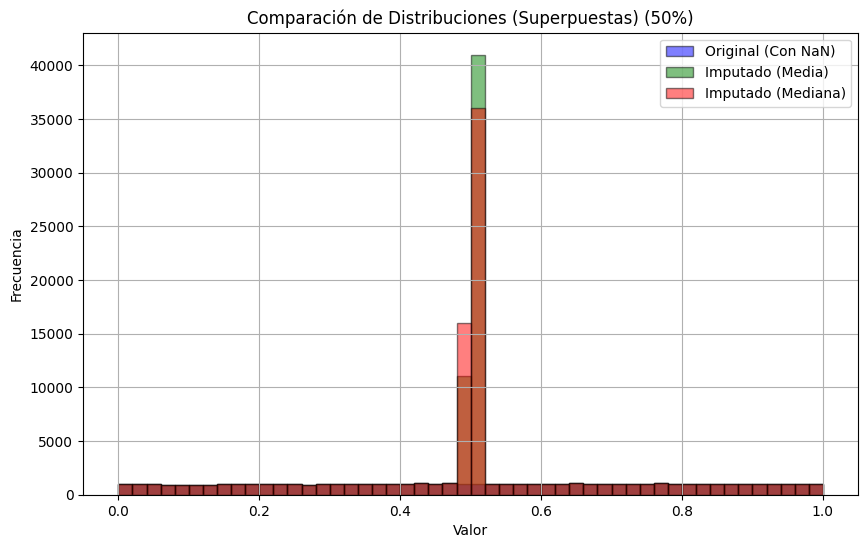

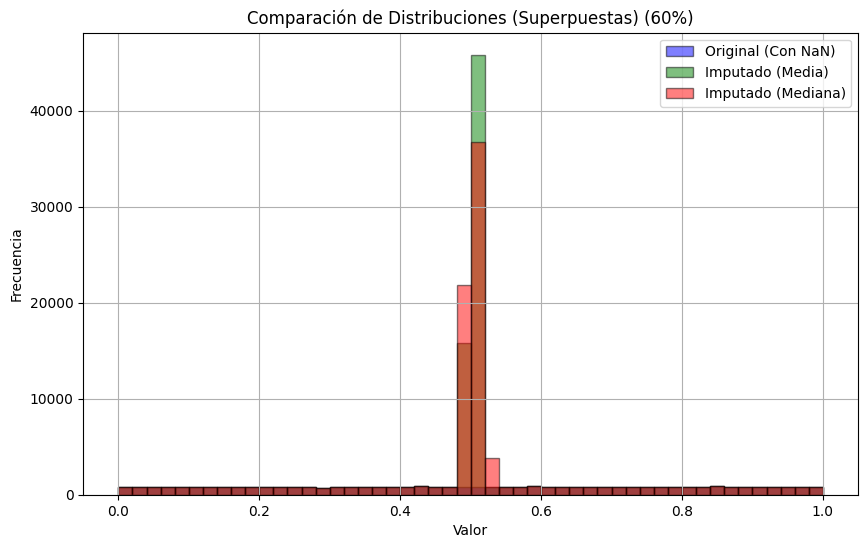

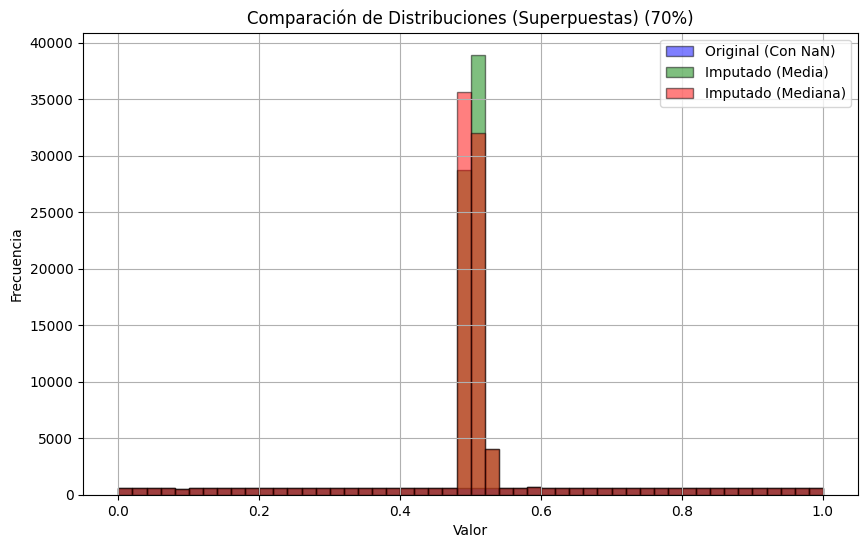

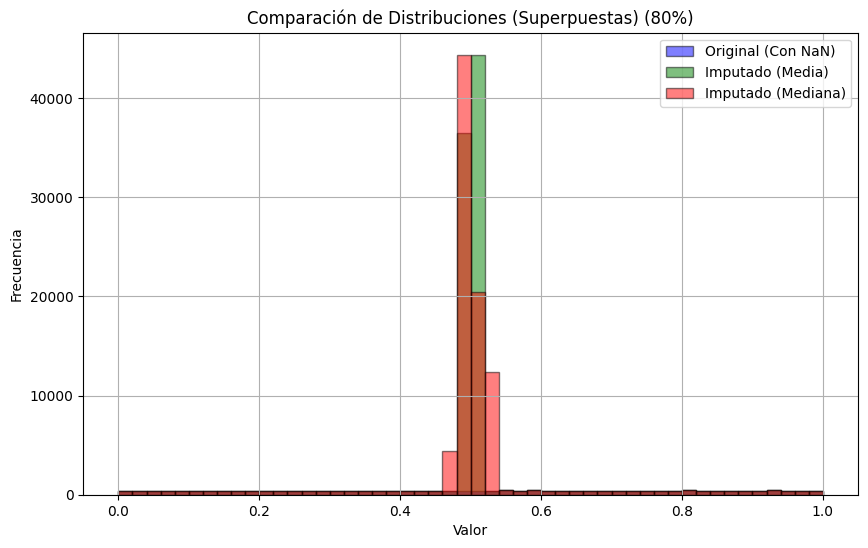

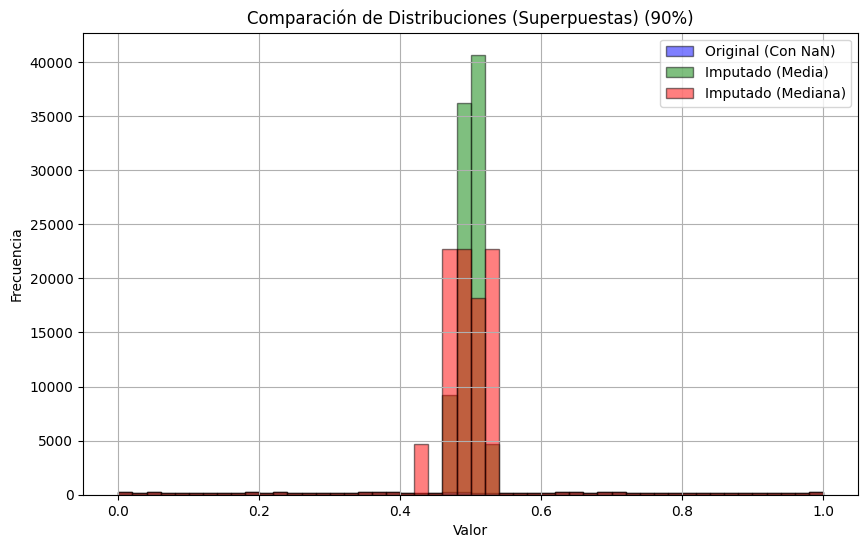

In [ ]:
for porcentaje in porcentajes_nan:

    # Genera un histograma superpuesto
    plt.figure(figsize=(10, 6))

    # Histograma de la matriz original
    plt.hist(matrices_con_nan[porcentaje].flatten(), bins=50, alpha=0.5, color='blue', edgecolor='black', label='Original (Con NaN)')

    # Histograma de la matriz imputada con media
    plt.hist(matrices_imputadas_media_clases[porcentaje].flatten(), bins=50, alpha=0.5, color='green', edgecolor='black', label='Imputado (Media)')

    # Histograma de la matriz imputada con mediana
    plt.hist(matrices_imputadas_mediana_clases[porcentaje].flatten(), bins=50, alpha=0.5, color='red', edgecolor='black', label='Imputado (Mediana)')

    # Configuración del gráfico
    plt.title(f"Comparación de Distribuciones (Superpuestas) ({porcentaje}%)")
    plt.xlabel("Valor")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.grid(True)

    # Mostrar el gráfico
    plt.show()


## 📊 Evaluación del Impacto de la Imputación  

Para evaluar la precisión de las técnicas de imputación, se calcula el **Error Cuadrático Medio (MSE)** comparando los valores imputados con los valores originales en las posiciones donde originalmente había datos faltantes. Este cálculo se realiza de manera separada para la imputación por **media** y por **mediana**, almacenando los errores obtenidos para cada porcentaje de valores ausentes.

El cálculo del MSE se enfoca exclusivamente en los valores que fueron eliminados, asegurando que la evaluación refleje con precisión la calidad de la imputación. Se espera que, a medida que aumenta el porcentaje de datos faltantes, el error también incremente debido a la mayor incertidumbre en la reconstrucción de los valores perdidos.

Al final, los valores de MSE obtenidos permiten analizar cómo afecta el porcentaje de datos faltantes a la calidad de la imputación y comparar qué método ofrece un mejor desempeño en distintas condiciones.  


In [ ]:
# Diccionarios para almacenar los errores MSE
errores_mse_media = {}
errores_mse_mediana = {}

# Calcular el error MSE para cada porcentaje de valores faltantes
for porcentaje in porcentajes_nan:
    # Máscara para seleccionar solo los valores originalmente faltantes
    mascara_nan = np.isnan(matrices_con_nan[porcentaje])

    # Calcular el MSE solo en las posiciones donde había NaN
    mse_media = mean_squared_error(
        matriz[mascara_nan], matrices_imputadas_media_clases[porcentaje][mascara_nan]
    )
    mse_mediana = mean_squared_error(
        matriz[mascara_nan], matrices_imputadas_mediana_clases[porcentaje][mascara_nan]
    )

    # Guardar los errores
    errores_mse_media[porcentaje] = mse_media
    errores_mse_mediana[porcentaje] = mse_mediana

# Mostrar los errores para cada método
errores_mse_media, errores_mse_mediana


({5: 0.08042478146562634,
  10: 0.08240287957252199,
  20: 0.08295995782171249,
  30: 0.08317857404430419,
  40: 0.08275907982263998,
  50: 0.08320646900452812,
  60: 0.0827355089030243,
  70: 0.08297763941393692,
  80: 0.08277116400789648,
  90: 0.08296809413892581},
 {5: 0.08049336583583826,
  10: 0.0824269352355455,
  20: 0.0830287592511661,
  30: 0.08322097050696271,
  40: 0.0828322475219058,
  50: 0.08327215790744265,
  60: 0.08282439506774446,
  70: 0.08301633871039568,
  80: 0.08292207045186767,
  90: 0.08347842191220095})

## ⚠️ Comparación de Errores de Imputación  

Para evaluar cómo afecta el porcentaje de valores faltantes a la precisión de la imputación, se grafica el **Error Cuadrático Medio (MSE)** en función del porcentaje de datos ausentes. Se comparan dos métodos:  

- **Imputación por Media:** Se observa cómo varía el error cuando los valores faltantes son reemplazados por la media de cada columna.  
- **Imputación por Mediana:** Se analiza el comportamiento del error cuando la imputación se realiza utilizando la mediana.  

Cada método se representa con una curva en el gráfico, permitiendo visualizar tendencias y diferencias entre ambos enfoques. Se espera que, a medida que el porcentaje de valores faltantes aumente, el error también crezca, reflejando la pérdida de información en los datos originales.  

Este análisis ayuda a determinar cuál de las dos técnicas es más robusta ante diferentes niveles de datos faltantes.  


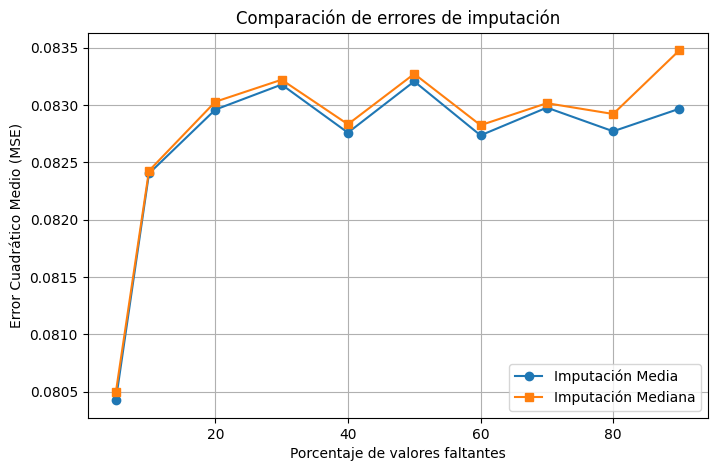

In [ ]:
# Crear la figura
plt.figure(figsize=(8, 5))

# Graficar los errores MSE para cada método
plt.plot(porcentajes_nan, list(errores_mse_media.values()), marker='o', linestyle='-', label="Imputación Media")
plt.plot(porcentajes_nan, list(errores_mse_mediana.values()), marker='s', linestyle='-', label="Imputación Mediana")

# Etiquetas y título
plt.xlabel("Porcentaje de valores faltantes")
plt.ylabel("Error Cuadrático Medio (MSE)")
plt.title("Comparación de errores de imputación")
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.show()

## 📊 Análisis de la Gráfica  
  - Vemos que a medida que aumentamos de porcentaje de valores faltantes el MSE sube.
  - **La imputación por media es mejor**, con menor variabilidad en el error.  

## 🔍 Imputación en Datos con Distribución Normal  

Aplicamos los mismos métodos de imputación (media y mediana) a una nueva matriz de datos que sigue una **distribución normal** (media=80, desviación estándar=20).  

Al igual que antes:  
- Introducimos valores faltantes en distintos porcentajes (10%-90%).  
- Evaluamos cómo la imputación afecta la distribución mediante histogramas.  
- Calculamos el **MSE** para comparar la precisión de cada método.  
- Visualizamos la evolución del error a medida que aumenta la cantidad de NaN.  

Este caso nos permite analizar cómo se comportan los métodos en datos normalmente distribuidos y verificar si las conclusiones previas se mantienen.  

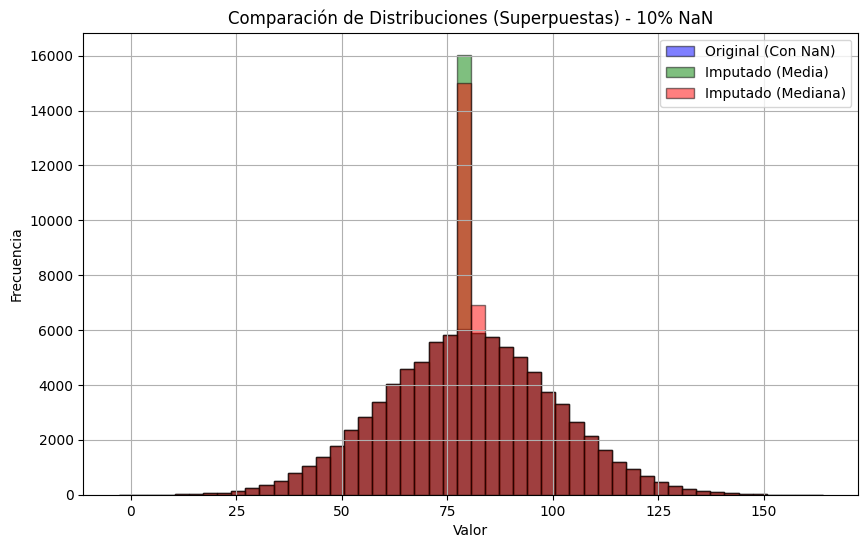

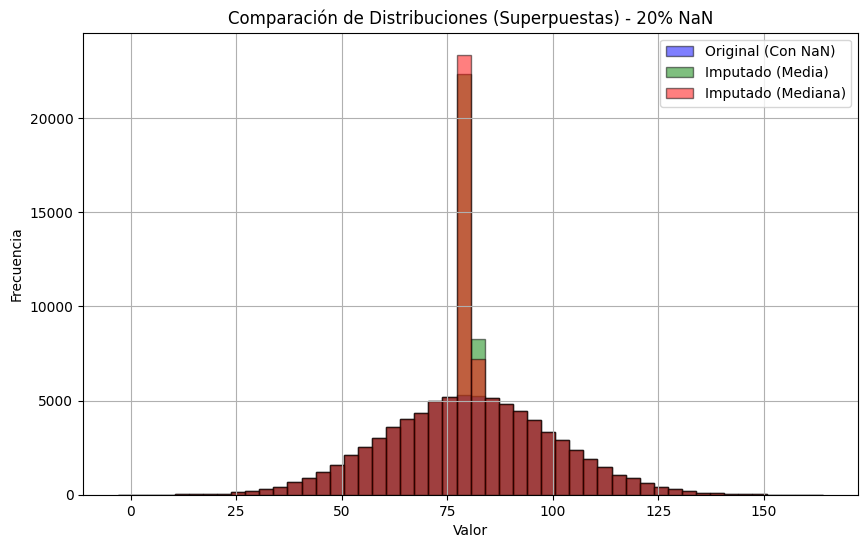

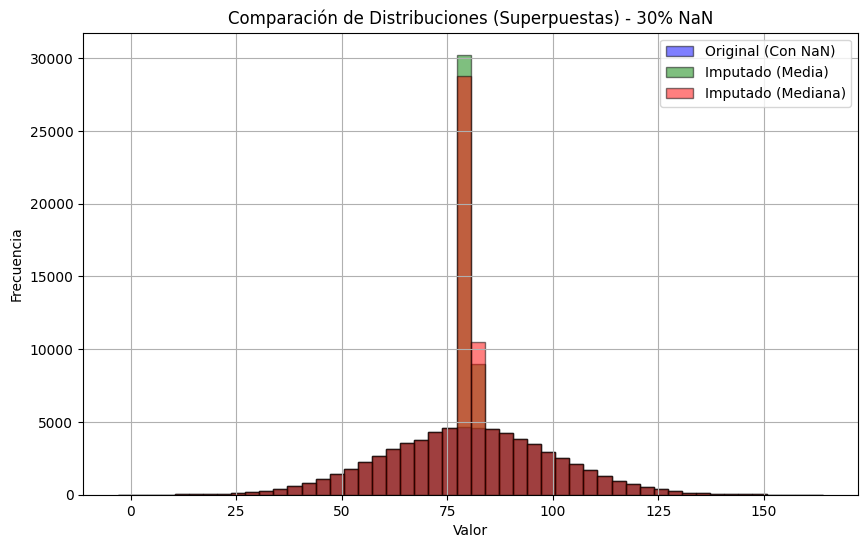

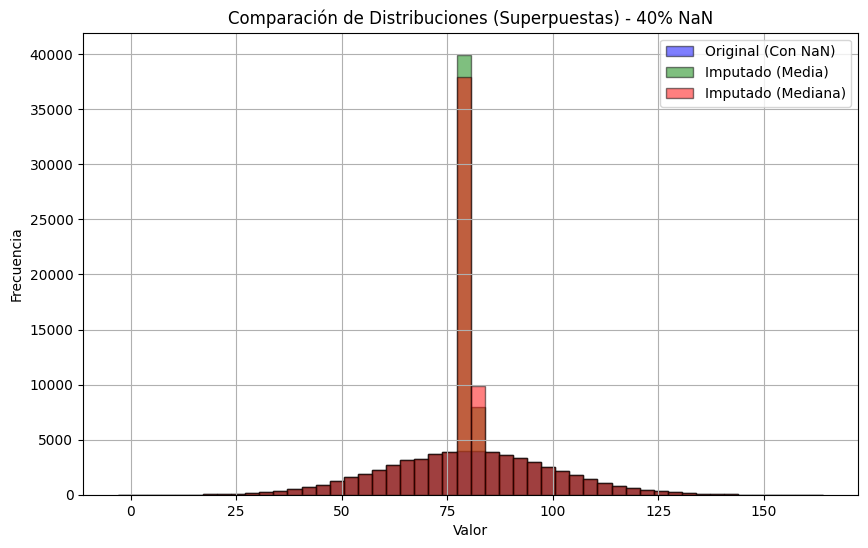

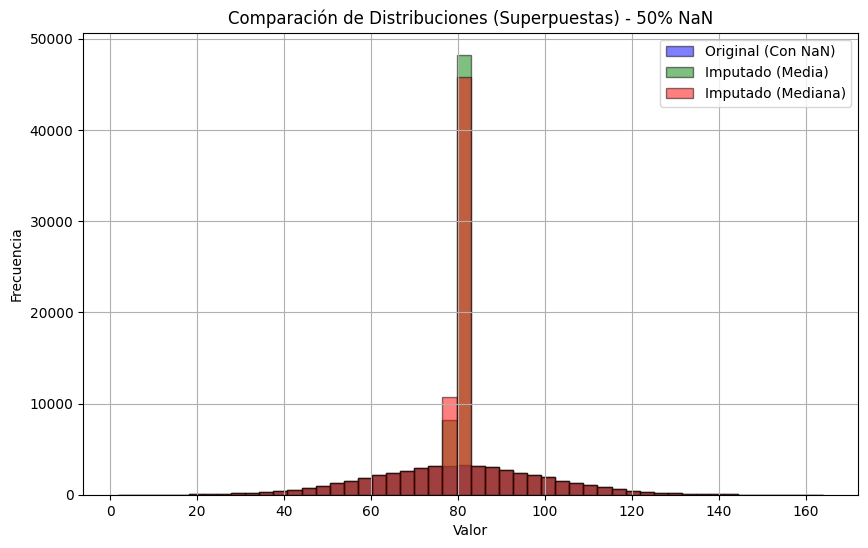

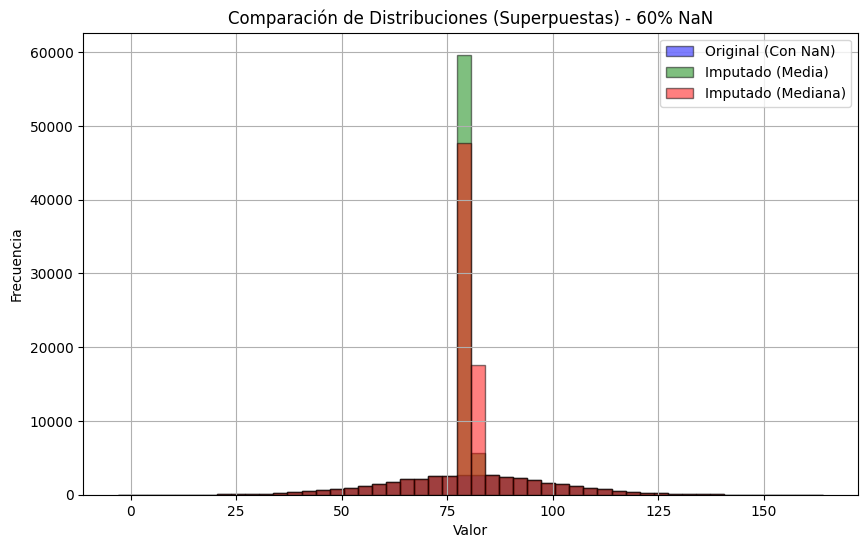

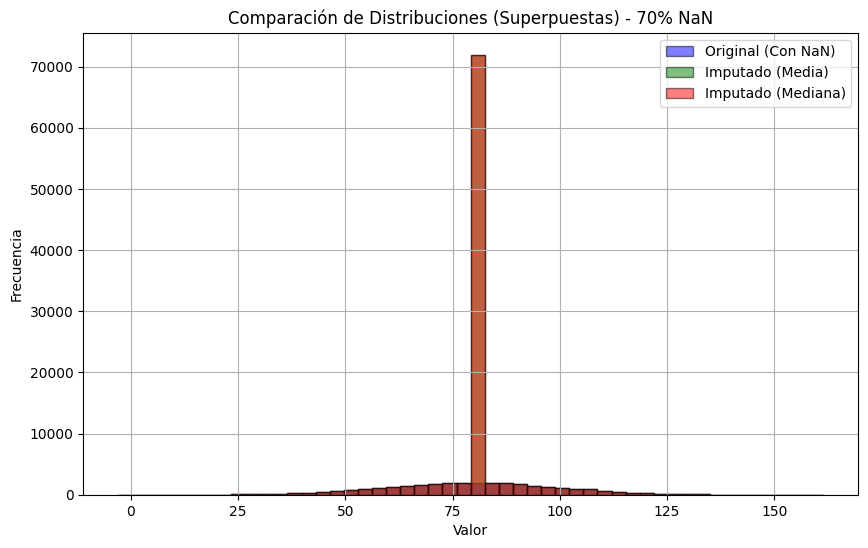

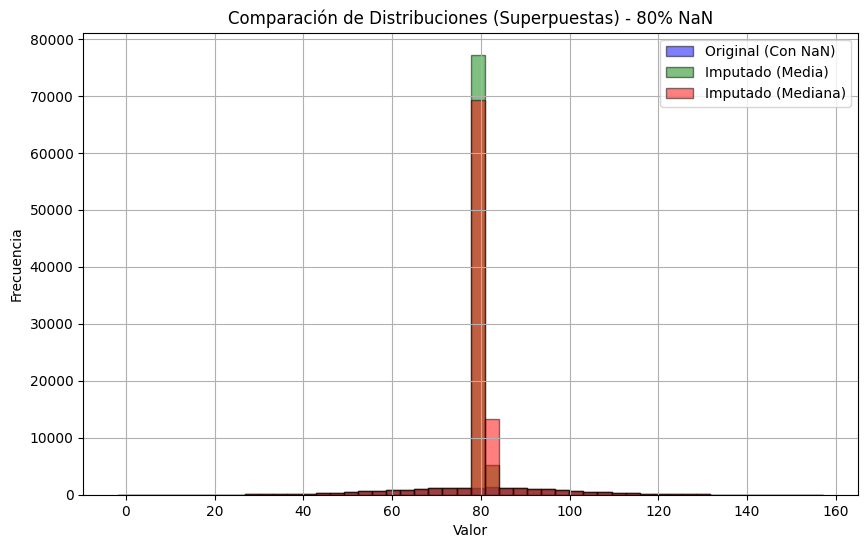

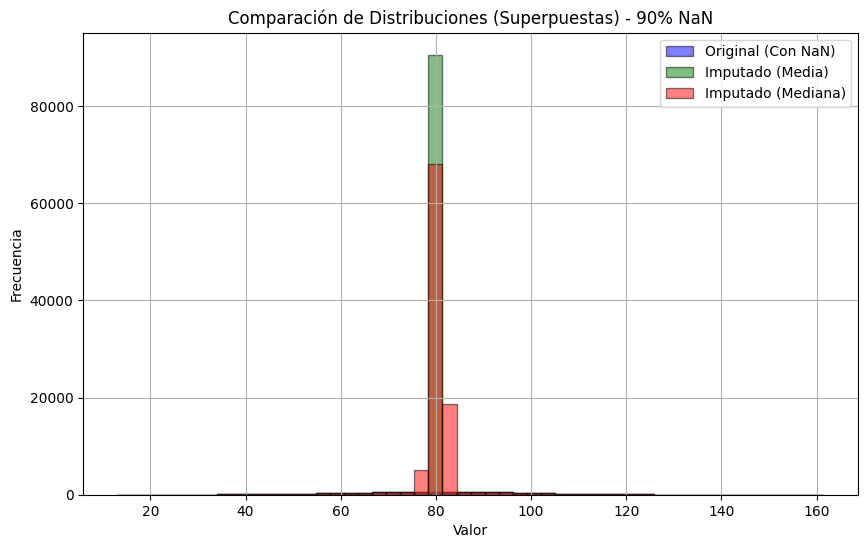

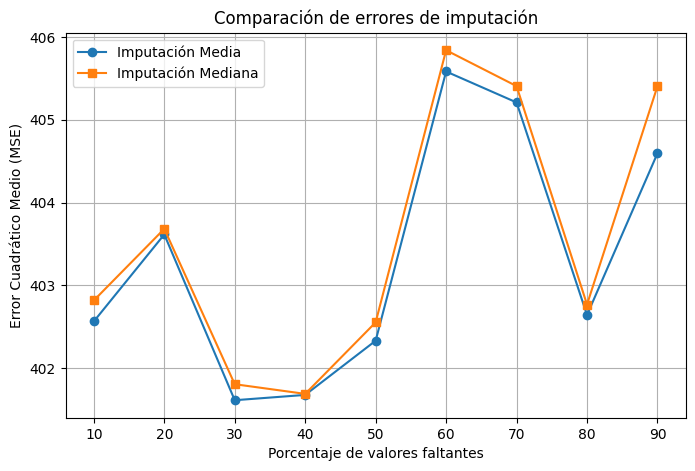

In [ ]:
np.random.seed(43)

# Crear una matriz de 5000x20 con valores distribuidos normalmente (media=80, desviación estándar=20)
matriz = np.random.normal(loc=80, scale=20, size=(5000, 20))

porcentajes_nan = [10, 20, 30, 40, 50, 60, 70, 80, 90]

# Crear diccionarios para almacenar matrices con NaN
matrices_con_nan = {}

# Obtener el número total de valores en la matriz
total_valores = matriz.size

# Introducir valores faltantes para cada porcentaje
np.random.seed(67613)
for porcentaje in porcentajes_nan:
    matriz_nan = matriz.copy()
    num_nan = int((porcentaje / 100) * total_valores)

    # Seleccionar índices aleatorios para convertir en NaN
    indices = np.random.choice(total_valores, num_nan, replace=False)
    filas, columnas = np.unravel_index(indices, matriz.shape)

    # Insertar NaN en la matriz
    matriz_nan[filas, columnas] = np.nan

    # Guardar la matriz con valores faltantes
    matrices_con_nan[porcentaje] = matriz_nan

# Diccionarios para almacenar matrices imputadas
matrices_imputadas_media = {}
matrices_imputadas_mediana = {}

# Aplicar imputación a cada matriz con valores faltantes
for porcentaje, matriz_nan in matrices_con_nan.items():
    matrices_imputadas_media[porcentaje] = imputar_media(matriz_nan)
    matrices_imputadas_mediana[porcentaje] = imputar_mediana(matriz_nan)

# Generar histogramas superpuestos para cada porcentaje
for porcentaje in porcentajes_nan:
    plt.figure(figsize=(10, 6))

    # Histograma de la matriz original con NaN
    plt.hist(matrices_con_nan[porcentaje].flatten(), bins=50, alpha=0.5, color='blue', edgecolor='black', label='Original (Con NaN)')

    # Histograma de la matriz imputada con media
    plt.hist(matrices_imputadas_media[porcentaje].flatten(), bins=50, alpha=0.5, color='green', edgecolor='black', label='Imputado (Media)')

    # Histograma de la matriz imputada con mediana
    plt.hist(matrices_imputadas_mediana[porcentaje].flatten(), bins=50, alpha=0.5, color='red', edgecolor='black', label='Imputado (Mediana)')

    # Configuración del gráfico
    plt.title(f"Comparación de Distribuciones (Superpuestas) - {porcentaje}% NaN")
    plt.xlabel("Valor")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.grid(True)

    # Mostrar el gráfico
    plt.show()

# Diccionarios para almacenar los errores MSE
errores_mse_media = {}
errores_mse_mediana = {}

# Calcular el error MSE para cada porcentaje de valores faltantes
for porcentaje in porcentajes_nan:
    # Máscara para seleccionar solo los valores originalmente faltantes
    mascara_nan = np.isnan(matrices_con_nan[porcentaje])

    # Calcular el MSE solo en las posiciones donde había NaN
    mse_media = mean_squared_error(
        matriz[mascara_nan], matrices_imputadas_media[porcentaje][mascara_nan]
    )
    mse_mediana = mean_squared_error(
        matriz[mascara_nan], matrices_imputadas_mediana[porcentaje][mascara_nan]
    )

    # Guardar los errores
    errores_mse_media[porcentaje] = mse_media
    errores_mse_mediana[porcentaje] = mse_mediana

# Graficar los errores MSE
plt.figure(figsize=(8, 5))
plt.plot(porcentajes_nan, list(errores_mse_media.values()), marker='o', linestyle='-', label="Imputación Media")
plt.plot(porcentajes_nan, list(errores_mse_mediana.values()), marker='s', linestyle='-', label="Imputación Mediana")

# Etiquetas y título
plt.xlabel("Porcentaje de valores faltantes")
plt.ylabel("Error Cuadrático Medio (MSE)")
plt.title("Comparación de errores de imputación")
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.show()

## 📌 Conclusión del estudio en general

El análisis realizado nos permitió comparar distintos métodos de imputación en matrices con valores faltantes. Entre los principales hallazgos encontramos que:  

- **El error cuadrático medio (MSE) aumenta** a medida que el porcentaje de valores faltantes es mayor, lo que indica que la recuperación de datos se vuelve menos precisa conforme la pérdida de información es más significativa.  
- **La imputación por media mostró mejor desempeño** en términos de error, manteniendo una menor variabilidad en comparación con la mediana. Esto sugiere que en los datos analizados, la media es un método más estable y preciso para la reconstrucción de valores perdidos.  

En general, estos resultados refuerzan la importancia de seleccionar cuidadosamente el método de imputación según las características de los datos, ya que algunos enfoques pueden ser más robustos y ofrecer mejores resultados en determinadas situaciones.  
